In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [3]:
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205_fillna.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


In [ ]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose Gene Body
        ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    # .with_columns(
    #     core_promoter = pl.col('dist_to_tss').abs() <= 50,
    #     encode_annotated = pl.col('not_in_encode') == False,
    #     encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
    #     encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    # )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        # set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

loftee_hc,cadd_raw,loftee_disorder,score_pai3d,consequence_synonymous_variant,am_pathogenicity,delta_score,pangolin_score,loftee_lip,loftee_ted,five_prime_utr_variant_consequence_ustop_gained,consequence_frameshift_variant,id,esmscoremissense,five_prime_utr_variant_consequence_ustop_lost,five_prime_utr_variant_consequence_uaug_gained,consequence_stop_gained,gpn_score,low_complexity_domain,consequence_splice_acceptor_variant,loftee_lc,absplice2_max,ted_domain,abexp_abs_max,loftee_low_complexity,absplice_dna_max,mobi_lip_full,consequence_splice_donor_variant,consequence_stop_lost,consequence_missense_variant,mobi_curated_disorder_priority,promoterai,five_prime_utr_variant_consequence_uaug_lost,consequence_start_lost,region,verphylop
i8,f32,bool,f32,i8,f32,f32,f32,bool,bool,u8,i8,str,f32,u8,u8,i8,f32,bool,i8,i8,f32,bool,f32,bool,f32,bool,i8,i8,i8,bool,f32,u8,i8,str,f32
0,3.681756,false,0.699444,0,0.2063,0.05,0.03,false,false,0,0,"""chr5:87376465:A:T""",-4.246,0,0,0,-11.54,false,0,0,0.000327,false,0.060269,false,0.003,false,0,0,1,false,0.0,0,0,"""ENSG00000145715""",8.687
1,7.69086,false,0.0,0,0.0,0.0,0.06,true,false,0,0,"""chr1:177933615:G:A""",0.0,0,0,1,-1.6,false,0,0,0.002165,false,0.946601,false,0.003,true,0,0,0,false,0.0,0,0,"""ENSG00000120341""",2.372
0,0.528766,false,0.0,1,0.0,0.0,0.0,false,false,0,0,"""chr2:96816550:C:T""",0.0,0,0,0,0.36,false,0,0,0.000033,false,0.012463,false,0.001,false,0,0,0,false,-0.143,0,0,"""ENSG00000168763""",-1.5
0,3.032575,false,0.0,0,0.0,0.08,0.03,false,false,0,0,"""chr2:178598858:G:A""",-6.253,0,0,0,-8.09,false,0,0,0.000034,false,0.015385,false,0.0,true,0,0,1,false,0.0,0,0,"""ENSG00000155657""",6.948
0,4.428444,false,0.550982,0,0.2002,0.0,0.0,false,false,0,0,"""chr2:128318064:C:T""",-5.721,0,0,0,-5.12,false,0,0,0.000321,true,0.160049,false,0.003,false,0,0,1,false,0.0,0,0,"""ENSG00000136720""",-0.102
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1,5.248261,false,0.0,0,0.0,0.01,0.03,false,true,0,0,"""chr4:15816634:C:A""",0.0,0,0,1,-6.74,false,0,0,0.002172,true,1.39091,false,0.003,false,0,0,0,false,0.0032,0,0,"""ENSG00000004468""",-0.6
0,1.2186,false,0.0,1,0.0,0.0,0.0,false,false,0,0,"""chr15:78077599:C:A""",0.0,0,0,0,-4.14,true,0,0,0.000033,false,0.013111,false,0.001,false,0,0,0,false,-0.0234,0,0,"""ENSG00000167202""",0.709
0,0.213689,false,0.0,1,0.0,0.0,0.0,false,false,0,0,"""chr14:67783209:G:A""",0.0,0,0,0,-0.88,false,0,0,0.000033,true,0.006189,false,0.001,true,0,0,0,false,0.0,0,0,"""ENSG00000072121""",2.934


In [5]:
selected_annos = anno_config_df.filter(
    # pl.col('category').is_in(['vep_consequences']) # VEP CDS consequences
    # pl.col('category').is_in(['plof_consequences']) # VEP plof consequences
    (pl.col('category').is_in(['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'])) # CDS
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation'])) # missense
    # (pl.col('category').is_in(['protein_domains'])) # protein domains
    # (pl.col('category').is_in(['loftee_protein_domains'])) # protein domains
    # (pl.col('category').is_in(['splicing', 'genetic_diversity', 'conservation'])) # synonymous

    # (pl.col('category').is_in(['splicing', 'conservation', 'regulatory_nondir', 'genetic_diversity'])) # non coding
    # (pl.col('category').is_in(['encode_regions'])) # encode regions
    # (pl.col('category').is_in(['encode_custom'])) # encode regions custom
    # (pl.col('category').is_in(['conservation', 'regulatory_nondir', 'genetic_diversity'])) # 5UTR
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr5:87376465:A:T""","""ENSG00000145715""","""loftee_hc""",0.0
"""chr1:177933615:G:A""","""ENSG00000120341""","""loftee_hc""",1.0
"""chr2:96816550:C:T""","""ENSG00000168763""","""loftee_hc""",0.0
"""chr2:178598858:G:A""","""ENSG00000155657""","""loftee_hc""",0.0
"""chr2:128318064:C:T""","""ENSG00000136720""","""loftee_hc""",0.0
…,…,…,…
"""chr4:15816634:C:A""","""ENSG00000004468""","""abexp_abs_max""",1.39091
"""chr15:78077599:C:A""","""ENSG00000167202""","""abexp_abs_max""",0.013111
"""chr14:67783209:G:A""","""ENSG00000072121""","""abexp_abs_max""",0.006189


In [6]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [7]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [8]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")

    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    # .group_by(["region", "gene_name", "phenotype", "annotation"])
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')
correlation_df

Executing the full lazy plan with the streaming engine...


region,phenotype,annotation,n_variants,correlation
str,str,str,u64,f64
"""ENSG00000119681""","""standing_height_int""","""verphylop""",1462,0.018878
"""ENSG00000008710""","""haemoglobin_concentration_int""","""delta_score""",5520,-0.011204
"""ENSG00000168769""","""red_blood_cell_erythrocyte_cou…","""delta_score""",1619,-0.01439
"""ENSG00000125844""","""cholesterol_int""","""delta_score""",1004,-0.030222
"""ENSG00000072274""","""mean_corpuscular_volume_int""","""absplice_dna_max""",507,-0.113714
…,…,…,…,…
"""ENSG00000205758""","""monocyte_count_int""","""delta_score""",244,-0.028516
"""ENSG00000155827""","""mean_corpuscular_volume_int""","""absplice2_max""",656,-0.042582
"""ENSG00000132855""","""triglycerides_int""","""absplice_dna_max""",278,-0.007314


In [9]:
# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    correlation_df
    .filter(pl.col('annotation')!='loftee_hc')
    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)
print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (25113, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000119681""","""standing_height_int""","""verphylop""",1462,0.018878,"""#942c80""","""Vertebrate PhyloP""",1,2.2425e-7,0.109201,0.109201,1.0,0.018878,0.172874
"""ENSG00000008710""","""haemoglobin_concentration_int""","""delta_score""",5520,-0.011204,"""#28a745""","""SpliceAI""",1,0.01172,-0.071223,0.071223,-1.0,0.011204,0.157313
"""ENSG00000168769""","""red_blood_cell_erythrocyte_cou…","""delta_score""",1619,-0.01439,"""#28a745""","""SpliceAI""",1,0.001948,-0.063183,0.063183,-1.0,0.01439,0.227754
"""ENSG00000125844""","""cholesterol_int""","""delta_score""",1004,-0.030222,"""#28a745""","""SpliceAI""",1,4.2084e-9,-0.143996,0.143996,-1.0,0.030222,0.209883
"""ENSG00000072274""","""mean_corpuscular_volume_int""","""absplice_dna_max""",507,-0.113714,"""#28a745""","""AbSplice (max)""",1,3.2617e-43,-0.23338,0.23338,-1.0,0.113714,0.487249
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000142173""","""heel_bone_mineral_density_bmd_…","""pangolin_score""",1076,0.081285,"""#28a745""","""Pangolin""",1,0.042155,0.075934,0.075934,1.0,0.081285,1.070476
"""ENSG00000205758""","""monocyte_count_int""","""delta_score""",244,-0.028516,"""#28a745""","""SpliceAI""",1,0.029094,-0.15102,0.15102,-1.0,0.028516,0.188821
"""ENSG00000155827""","""mean_corpuscular_volume_int""","""absplice2_max""",656,-0.042582,"""#28a745""","""AbSplice2 (max)""",1,1.3489e-12,-0.145685,0.145685,-1.0,0.042582,0.292285


In [10]:
# correlation_df.write_parquet(f'/home/dnanexus/data_dir/results/correlations_all_vars_wgs_EUR_genebass1e6_maf1e3.parquet')
# correlation_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/correlations_all_vars_wgs_EUR_genebass1e6_maf1e3.parquet')

In [11]:

consistent_gt = (
    correlation_df
    # .filter(pl.col('annotation')!='promoterai_abs')
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)  # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000119681""","""standing_height_int""","""verphylop""",1462,0.018878,"""#942c80""","""Vertebrate PhyloP""",1,2.2425e-7,0.109201,0.109201,1.0,0.018878,0.172874,11
"""ENSG00000008710""","""haemoglobin_concentration_int""","""delta_score""",5520,-0.011204,"""#28a745""","""SpliceAI""",1,0.01172,-0.071223,0.071223,-1.0,0.011204,0.157313,11
"""ENSG00000072274""","""mean_corpuscular_volume_int""","""absplice_dna_max""",507,-0.113714,"""#28a745""","""AbSplice (max)""",1,3.2617e-43,-0.23338,0.23338,-1.0,0.113714,0.487249,11
"""ENSG00000085741""","""peak_expiratory_flow_pef_int""","""gpn_score""",232,0.024246,"""#942c80""","""GPN-MSA""",-1,0.020341,-0.09011,0.09011,-1.0,0.024246,0.269075,11
"""ENSG00000131504""","""mean_platelet_thrombocyte_volu…","""absplice2_max""",845,0.002859,"""#28a745""","""AbSplice2 (max)""",1,1.1225e-8,0.132184,0.132184,1.0,0.002859,0.021631,11
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000178177""","""arm_predicted_mass_left_int""","""cadd_raw""",1127,0.062708,"""#1f77b4""","""CADD Raw""",1,5.7452e-11,0.159565,0.159565,1.0,0.062708,0.392992,11
"""ENSG00000142173""","""heel_bone_mineral_density_bmd_…","""pangolin_score""",1076,0.081285,"""#28a745""","""Pangolin""",1,0.042155,0.075934,0.075934,1.0,0.081285,1.070476,11
"""ENSG00000205758""","""monocyte_count_int""","""delta_score""",244,-0.028516,"""#28a745""","""SpliceAI""",1,0.029094,-0.15102,0.15102,-1.0,0.028516,0.188821,11


In [12]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


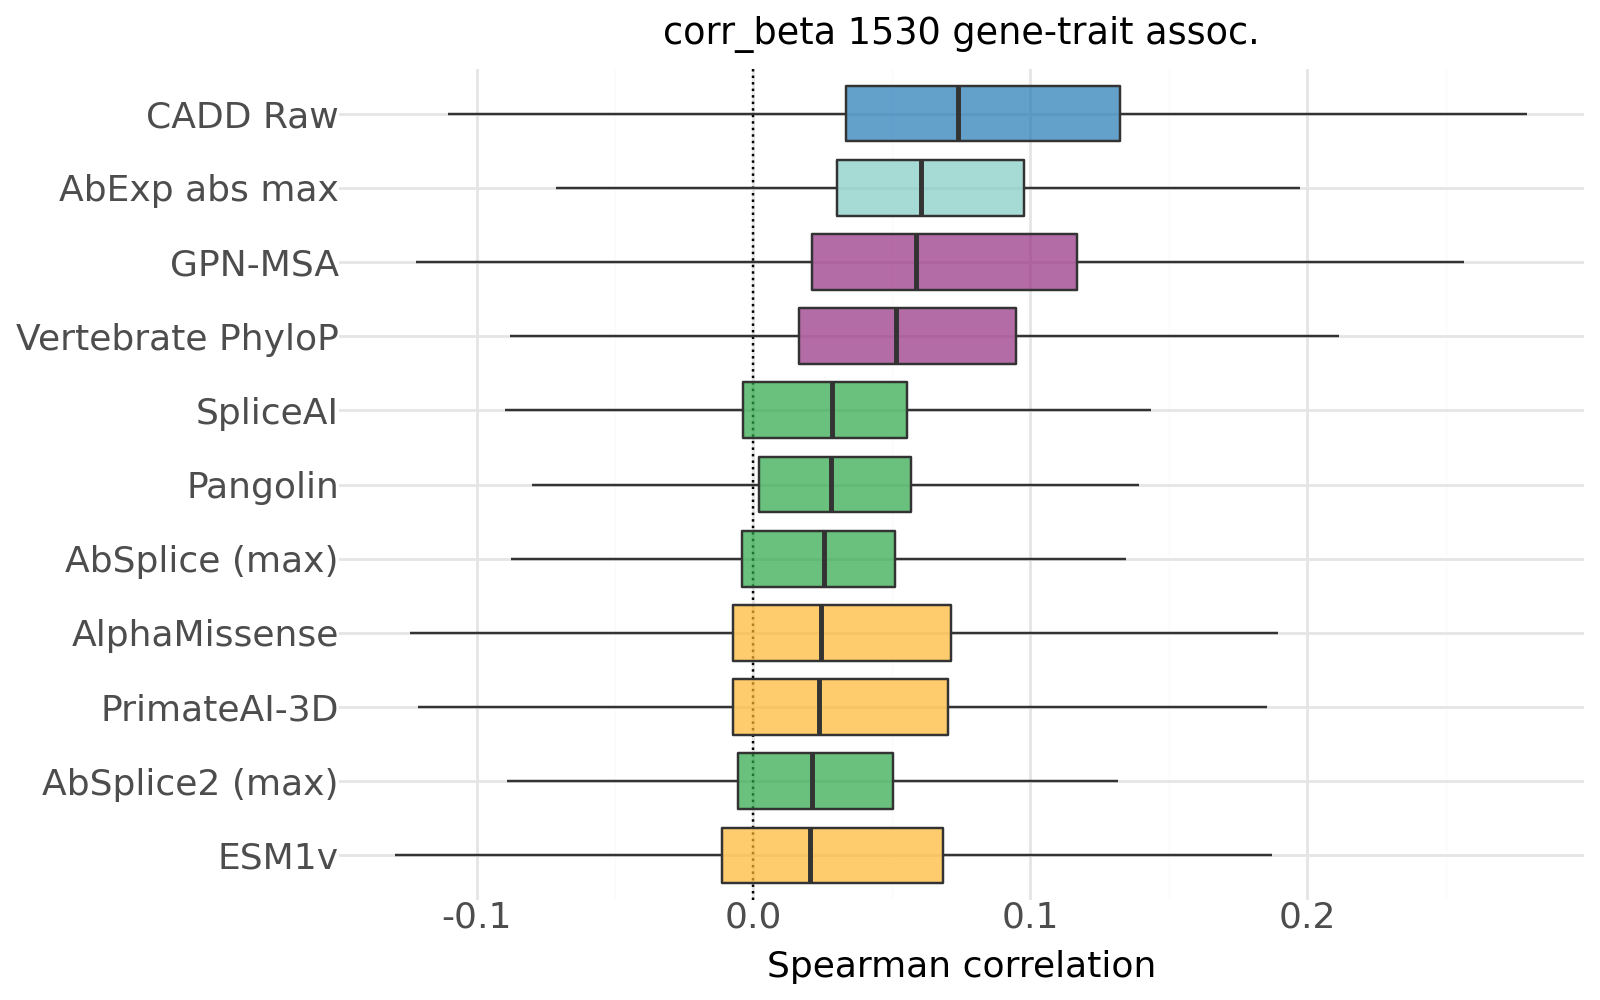

In [17]:
# Prepare for plotting
plotting_col = 'corr_beta'
# plotting_col = 'corr_beta_rescaled'

dashed_line_value = 1 if 'rescaled' in plotting_col else 0

med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta = pl.col(plotting_col).median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7)
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{plotting_col} {corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc."
        # \nGene body ±5kb"
        # \n VEP CDS variants"
        # \n Disorder region missense variants"
        # \n{variant_class} variants"
        # \nTSS [{min_range}bp, {max_range}bp]"
    )
    + coord_flip()
    + theme(
        figure_size=(8, 5),
        # figure_size=(8, 3.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [14]:
med_df.sort('median_corr_beta')

annotation,median_corr_beta
str,f64
"""esmscoremissense""",0.227723
"""absplice2_max""",0.23639
"""score_pai3d""",0.245741
"""am_pathogenicity""",0.248536
"""absplice_dna_max""",0.26464
…,…
"""pangolin_score""",0.294854
"""verphylop""",0.534006
"""gpn_score""",0.60893


In [15]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_117232/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""cadd_raw""","""score_pai3d""",1530,17165.0,3.3474e-237
"""cadd_raw""","""esmscoremissense""",1530,22367.0,6.4207e-233
"""cadd_raw""","""am_pathogenicity""",1530,24819.0,6.4971e-231
"""cadd_raw""","""verphylop""",1530,80512.0,1.0107e-187
"""gpn_score""","""score_pai3d""",1530,91147.0,5.4990e-180
…,…,…,…,…
"""delta_score""","""pangolin_score""",1530,531580.0,0.001773
"""delta_score""","""am_pathogenicity""",1530,539854.0,0.008119
"""absplice_dna_max""","""score_pai3d""",1530,539982.0,0.008299


In [16]:
stats_df.filter(
    (pl.col('VSM_A') == 'absplice2_max') | (pl.col('VSM_B') == 'absplice2_max')
)

VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""cadd_raw""","""absplice2_max""",1530,134304.0,2.7962e-150
"""absplice_dna_max""","""absplice2_max""",1530,521537.0,0.00021
"""esmscoremissense""","""absplice2_max""",1530,531063.0,0.001601
"""absplice2_max""","""gpn_score""",1530,219265.0,1.0680e-99
"""absplice2_max""","""verphylop""",1530,273539.0,7.2438e-73
"""absplice2_max""","""delta_score""",1530,513478.0,0.00003
"""absplice2_max""","""score_pai3d""",1530,509553.0,0.000011
"""absplice2_max""","""pangolin_score""",1530,469018.0,1.5273e-11
"""absplice2_max""","""abexp_abs_max""",1530,124775.0,1.3184e-156
